# MD Analysis Plotting

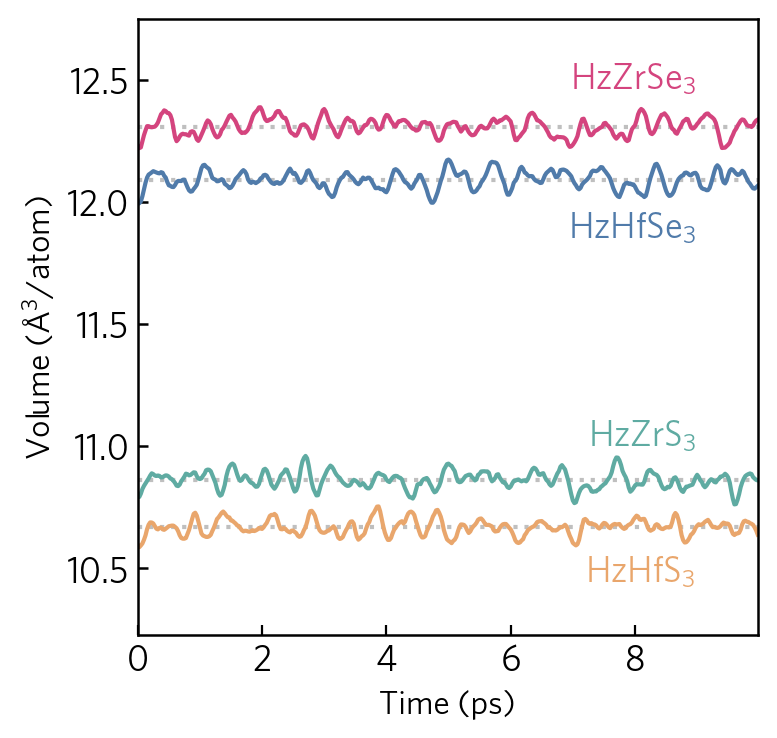

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import json
import matplotlib.transforms as transforms
from matplotlib.ticker import MaxNLocator

plt.style.use(["style.mplstyle"])

with open("../data/volume_data.json", "r") as f:
    md_volume_data = json.load(f)

def latexify(string):
    return string.replace("3", "$_3$")

def plot_volume_per_atom(ax):
    trans = transforms.blended_transform_factory(ax.transAxes, ax.transData)
    for i, (system, system_info) in enumerate(md_volume_data.items()):
        avg_volume = np.mean(system_info["volume_per_atom"]).mean()
        ax.axhline(avg_volume, color="gray", linestyle=":", alpha=0.5)
        ax.plot(np.array(system_info["time_fs"]) / 1000, system_info["volume_per_atom"])

        if "Zr" in system:
            ax.text(0.9, avg_volume * 1.01, latexify(system), transform=trans, ha="right", va="bottom", color=f"C{i}")
        else:
            ax.text(0.9, avg_volume * 0.99, latexify(system), transform=trans, ha="right", va="top", color=f"C{i}")

    ax.set(xlabel="Time (ps)", ylabel="Volume ($\mathrm{\AA}^3$/atom)")
    ax.margins(y=0.2, x=0)
    ax.yaxis.set_major_locator(MaxNLocator(6))
    ax.xaxis.set_major_locator(MaxNLocator(6))


fig, ax = plt.subplots(figsize=(4, 4))
plot_volume_per_atom(ax)


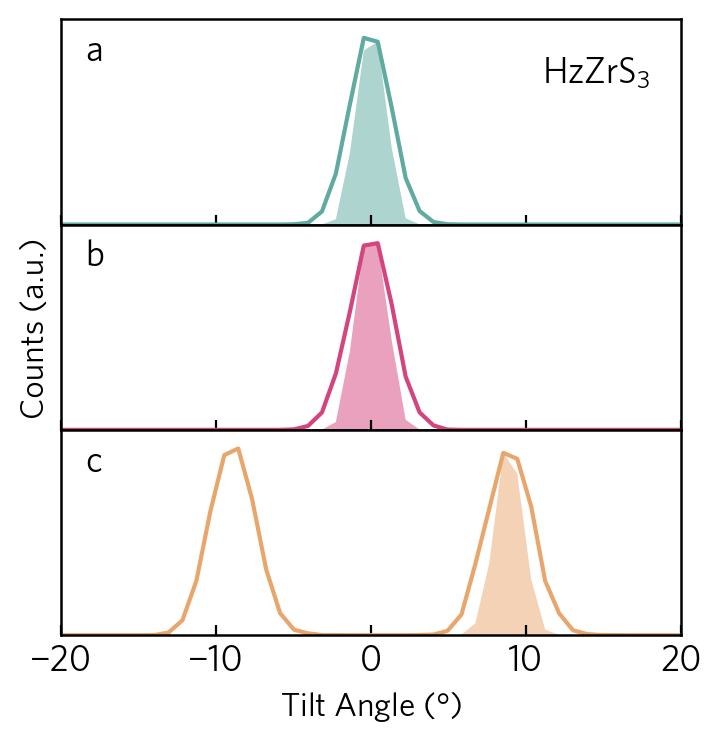

In [3]:
with open("../data/tilt_data.json", "r") as f:
    tilt_data = json.load(f)

colors = {'a': 'C0', 'b': 'C1', 'c': 'C2'}
fill_alpha = 0.5

def plot_tilt_histograms(material_name, axes, xlim=(-20, 20)):
    axis_data = tilt_data[material_name]
    
    for i, axis in enumerate(['a', 'b', 'c']):
        ax = axes[i]
        angles = axis_data[axis]["angle"]
        tilt_int = axis_data[axis]["tilt_intensity"]
        shaded_int = axis_data[axis]["shaded_intensity"]
        ax.plot(angles, tilt_int, color=colors[axis])
        ax.fill_between(angles, shaded_int, 0, 
                        facecolor=colors[axis], alpha=fill_alpha, interpolate=True)
        ax.text(0.04, 0.8, axis, transform=ax.transAxes)
        
        ax.set_ylim(0, 1.1)
        ax.set_yticks([]) 

    axes[1].set_ylabel("Counts (a.u.)")
    axes[-1].set(xlabel=r'Tilt Angle ($\degree$)', xlim=xlim)
    axes[0].text(0.95, 0.83, latexify(material_name), transform=axes[0].transAxes, ha='right', va='top')
    plt.subplots_adjust(hspace=0)
    
    for ax in axes[:-1]:
        ax.tick_params(labelbottom=False)
        ax.set_xlabel("")


fig, axes = plt.subplots(3, 1, figsize=(4, 4), sharex=True, sharey=True)
plot_tilt_histograms("HzZrS3", axes)

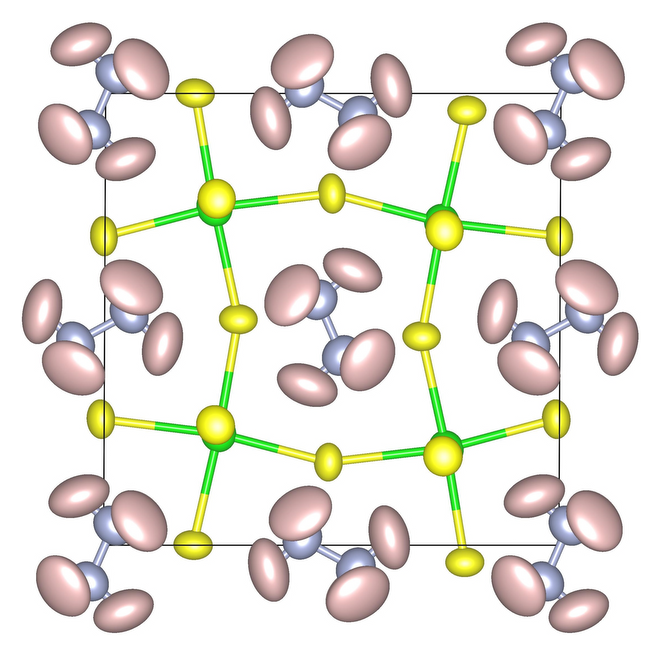

In [4]:
import matplotlib.image as mpimg

def plot_crystal_structure(ax, img_path, zoom_factor=1.0, center=(0.5, 0.5)):
    """
    Plots a crystal structure image onto an axis with zoom capabilities.
    
    Args:
        ax: The matplotlib axis to plot on.
        img_path: Path to the image file.
        zoom_factor: Float > 1.0 to zoom in, 1.0 for full view.
        center: Tuple (x_pct, y_pct) for the center of the zoom (0.0-1.0).
    """
    try:
        img = mpimg.imread(img_path)
        # ax.imshow(img)
        im = ax.imshow(img, aspect='auto', interpolation='lanczos')
        im.set_clip_on(False)
        
        # Image dimensions
        img_h, img_w = img.shape[:2]
        
        # Calculate view window dimensions
        view_w = img_w / zoom_factor
        view_h = img_h / zoom_factor
        
        # Calculate limits based on center percentage
        # (0,0) is top-left for images usually, but imshow origin defaults to upper
        center_x_px = img_w * center[0]
        center_y_px = img_h * center[1]
        
        x_min = center_x_px - (view_w / 2)
        x_max = center_x_px + (view_w / 2)
        y_min = center_y_px + (view_h / 2) 
        y_max = center_y_px - (view_h / 2) 

        # Enforce limits (imshow handles out-of-bound cropping gracefully usually, 
        # but clamping is safer if you want exact behavior)
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        
    except FileNotFoundError:
        ax.text(0.5, 0.5, "Image not found", ha='center', va='center')
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)

    ax.axis('off')

fig, ax = plt.subplots(figsize=(4, 4))
plot_crystal_structure(ax, "../thermal-cifs/HzZrSe3_averaged.jpg", zoom_factor=1)

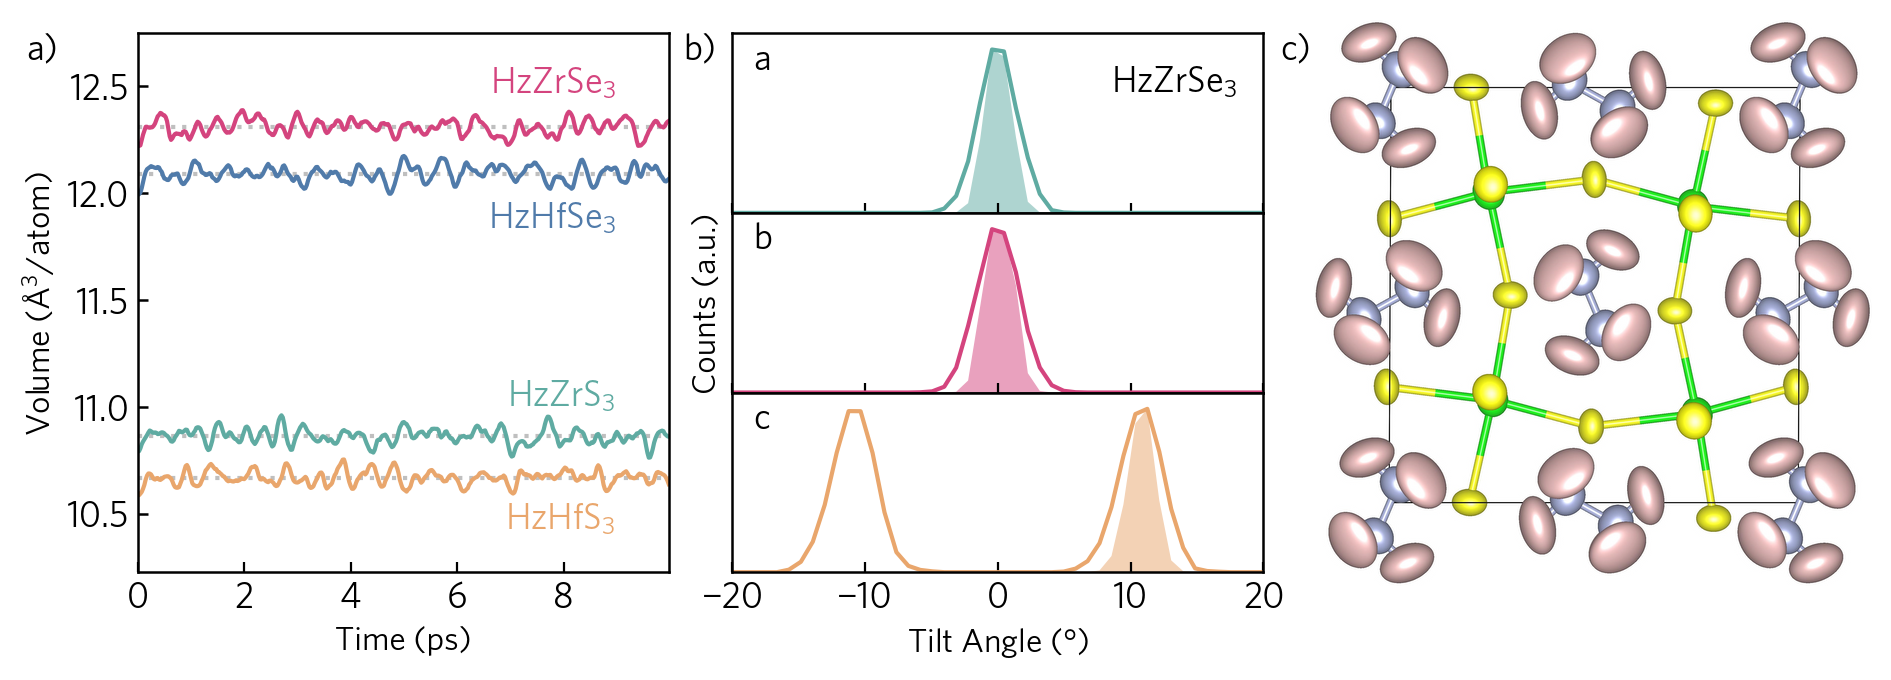

In [5]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(11.1, 3.5))

gs = gridspec.GridSpec(3, 3, figure=fig, width_ratios=[1, 1, 1])

ax_vol = fig.add_subplot(gs[:, 0])
plot_volume_per_atom(ax_vol)

ax_tilt_a = fig.add_subplot(gs[0, 1])
ax_tilt_b = fig.add_subplot(gs[1, 1], sharex=ax_tilt_a)
ax_tilt_c = fig.add_subplot(gs[2, 1], sharex=ax_tilt_a)
tilt_axes = [ax_tilt_a, ax_tilt_b, ax_tilt_c]
plot_tilt_histograms("HzZrSe3", tilt_axes)

ax_struc = fig.add_subplot(gs[:, 2])
plot_crystal_structure(ax_struc, "../thermal-cifs/HzZrSe3_averaged.jpg", zoom_factor=1.05, center=(0.5, 0.5))

ax_vol.text(-0.15, 1.0, 'a)', transform=ax_vol.transAxes, va='top', ha='right')
ax_tilt_a.text(-0.03, 1.0, 'b)', transform=ax_tilt_a.transAxes, va='top', ha='right')
ax_struc.text(-0.03, 1.0, 'c)', transform=ax_struc.transAxes, va='top', ha='right')

plt.subplots_adjust(wspace=0.12)
plt.savefig("../plots/md_summary.pdf", dpi=400, bbox_inches='tight', pad_inches=0)
